# Differentiable Abstraction Search

**Problem**: SoRL's abstraction search (Jacobi recursion) is non-differentiable — we sample discrete tokens, 
so gradients can't flow back through the search process to improve abstraction *selection*.

**Idea (STE-based)**: During the last iteration of Jacobi decoding, replace the hard `argmax`/`multinomial` 
with a Straight-Through Estimator (STE):

```
# Forward: use discrete token index for embedding lookup
# Backward: gradient flows through the soft logits
embedding = embed(sampled_index) + logit - stop_gradient(logit)
```

This means the forward pass still uses discrete tokens (so the model sees normal inputs),
but the backward pass has gradients w.r.t. the logits that produced those tokens.

**This notebook validates the core mechanism on a toy model** before integrating into SoRL:
1. Build a tiny MLP that predicts logits over an abstract vocab
2. Show that STE sampling is differentiable (gradients flow)
3. Show that Gumbel-Softmax is an alternative
4. Compare: hard sampling (no grad) vs STE vs Gumbel-Softmax
5. Train the toy model to optimize a downstream loss *through* the discrete sampling

In [1]:
# Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Using device: cpu


## Part 1: STE Primitives

Three ways to sample discrete tokens while keeping gradients:

1. **Hard sampling (baseline)** — `multinomial` → no gradient  
2. **STE** — forward uses discrete index, backward uses soft logits: `embed(idx) + logit - sg(logit)`  
3. **Gumbel-Softmax** — differentiable relaxation of categorical sampling

In [33]:
# ============================================================
# Core primitives: 3 ways to sample discrete tokens
# ============================================================

def sample_hard(logits, temperature=1.0):
    """Standard sampling — NO gradient through the sample."""
    probs = F.softmax(logits / temperature, dim=-1)
    idx = torch.multinomial(probs, num_samples=1).squeeze(-1)  # (B,)
    return idx  # detached from computation graph


# Insight #1. Exactly, the point of having "straight-through estimator" ver. of "one-hot" vector, is because we can do 
#.            differentiable embedding lookup
# Concern #1. Is probs the optimal way of using STE? (in terms of gradient dynamics and all that) Can we somehow work in the logit form?  
# Question #1. One feeling I had for Gumbel, is that the "soft" is 

def sample_ste(logits, temperature=1.0):
    """
    Normal Decoding + STE "one-hot" vector for differentiable embedding lookup
    """
    soft_probs = F.softmax(logits / temperature, dim=-1)       # (B, V) differentiable
    idx = torch.multinomial(soft_probs, num_samples=1).squeeze(-1)  # (B,) hard sample
    one_hot = F.one_hot(idx, num_classes=logits.size(-1)).float()   # (B, V)
    # STE: forward = one_hot, backward = soft_probs
    ste_probs = one_hot + soft_probs - soft_probs.detach()          # (B, V)
    return ste_probs, idx

def sample_gumbel_softmax(logits, temperature=1.0, hard=True):
    """
    Gumbel-Softmax: differentiable relaxation of categorical sampling.
    With hard=True, forward is one-hot but backward is soft.
    """
    soft = F.gumbel_softmax(logits, tau=temperature, hard=hard, dim=-1)  # (B, V)
    idx = soft.argmax(dim=-1)
    return soft, idx


# ---- Verify gradients flow ----
print("=== Gradient flow test ===\n")

V = 8  # small abstract vocab
logits = torch.randn(1, V, requires_grad=True)

# Test 1: Hard sampling — no gradient
idx_hard = sample_hard(logits, temperature=0.5)
# Can't backprop through idx_hard directly, so we use a dummy loss
# that depends on the index — gradient should NOT flow
dummy_embed = nn.Embedding(V, 4)
emb_hard = dummy_embed(idx_hard) # -> normal way to interact with embedding layer, using idx of shape (B,)
loss_hard = emb_hard.sum() # -> sum of embedding vector as the loss value
loss_hard.backward()
print(f"Hard sampling:    logits.grad = {logits.grad}")
# Expected: None (no gradient)

# Test 2: STE — gradient flows
logits2 = torch.randn(1, V, requires_grad=True)
ste_probs, idx_ste = sample_ste(logits2, temperature=0.5)
# Differentiable embedding lookup: matmul with embed weight
emb_ste = ste_probs @ dummy_embed.weight  # (B, 4)
loss_ste = emb_ste.sum()
loss_ste.backward()
print(f"STE sampling:     logits.grad = {logits2.grad is not None} | norm = {logits2.grad.norm().item():.4f}")

# Test 3: Gumbel-Softmax — gradient flows
logits3 = torch.randn(1, V, requires_grad=True)
gumbel_probs, idx_gumbel = sample_gumbel_softmax(logits3, temperature=0.5)
emb_gumbel = gumbel_probs @ dummy_embed.weight
loss_gumbel = emb_gumbel.sum()
loss_gumbel.backward()
print(f"Gumbel-Softmax:   logits.grad = {logits3.grad is not None} | norm = {logits3.grad.norm().item():.4f}")

print("\n✓ STE and Gumbel-Softmax both propagate gradients through discrete sampling.")

=== Gradient flow test ===

Hard sampling:    logits.grad = None
STE sampling:     logits.grad = True | norm = 0.2599
Gumbel-Softmax:   logits.grad = True | norm = 1.3841

✓ STE and Gumbel-Softmax both propagate gradients through discrete sampling.


## Part 2: Toy Model — Can we optimize *through* discrete token selection?

Setup: A tiny "abstract token predictor" (1-layer MLP) that takes a hidden state and predicts
which abstract token to insert. The downstream loss depends on the *chosen* token's embedding.

**Goal**: Show that STE lets us train the predictor to minimize a downstream loss that only
sees the discrete token — not the soft distribution.

In [37]:
# ============================================================
# Toy model: MLP predicts abstract token logits from hidden state
# Downstream loss depends on the chosen token's embedding
# ============================================================

# This is similar to SoRL, because it's ultimately the abstract token's embedding that got used for predicting NL tokens etc. 
# Not the abstract token idx, therefore, the toy prediction loss, being a function of the embedding, is indeed a truthful proxy of the actual SoRL loss.

class ToyAbstractPredictor(nn.Module):
    """
    Mimics the SoRL abstraction prediction:
    - Takes a hidden state h (like transformer hidden at an abstract position)
    - Predicts logits over abstract vocab
    - Samples a discrete token
    - Looks up that token's embedding
    - Downstream: the embedding is used to predict a target
    """
    def __init__(self, hidden_dim, abs_vocab_size, embed_dim):
        super().__init__()
        self.predictor = nn.Linear(hidden_dim, abs_vocab_size)  # h -> logits
        self.abs_embed = nn.Embedding(abs_vocab_size, embed_dim)  # abstract token embeddings
        self.downstream = nn.Linear(embed_dim, 1)  # downstream task head
        self.abs_vocab_size = abs_vocab_size

    def forward(self, h, temperature=1.0, method="ste"):
        """
        h: (B, hidden_dim)
        Returns: prediction, sampled_idx, logits
        """
        logits = self.predictor(h)  # (B, abs_vocab_size)

        if method == "hard":
            idx = sample_hard(logits, temperature)
            emb = self.abs_embed(idx)  # (B, embed_dim) — NO gradient to logits
        elif method == "ste":
            ste_probs, idx = sample_ste(logits, temperature)
            emb = ste_probs @ self.abs_embed.weight  # (B, embed_dim) — differentiable
        elif method == "gumbel":
            gumbel_probs, idx = sample_gumbel_softmax(logits, temperature)
            emb = gumbel_probs @ self.abs_embed.weight  # (B, embed_dim) — differentiable
        else:
            raise ValueError(f"Unknown method: {method}")

        pred = self.downstream(emb).squeeze(-1)  # (B,)
        return pred, idx, logits


# ---- Toy task: pick the token whose embedding gives output closest to target ----
H = 32       # hidden dim
V_abs = 16   # abstract vocab size
E = 16       # embed dim
B = 64       # batch size

model_toy = ToyAbstractPredictor(H, V_abs, E).to(device)

# Frozen target: for each hidden state h, there's an optimal abstract token
# We'll make the target depend on h so the predictor must learn
target_proj = nn.Linear(H, 1, bias=False).to(device)
for p in target_proj.parameters():
    p.requires_grad = False

print(f"Toy model: hidden={H}, abs_vocab={V_abs}, embed={E}")
print(f"Task: predict target = target_proj(h), choosing abstract tokens as intermediary")
print(f"Methods to compare: hard (no grad), STE, Gumbel-Softmax")

Toy model: hidden=32, abs_vocab=16, embed=16
Task: predict target = target_proj(h), choosing abstract tokens as intermediary
Methods to compare: hard (no grad), STE, Gumbel-Softmax


In [38]:
# ============================================================
# Train toy model with all 3 methods — compare convergence
# ============================================================

def train_toy(method, n_steps=500, lr=1e-3, temperature=0.5):
    """Train the toy abstract predictor with a given sampling method."""
    # Fresh model each time for fair comparison
    mdl = ToyAbstractPredictor(H, V_abs, E).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=lr)

    losses = []
    token_entropy = []  # track whether tokens collapse

    for step in range(n_steps):
        h = torch.randn(B, H, device=device)
        target = target_proj(h).squeeze(-1)  # (B,)

        pred, idx, logits = mdl(h, temperature=temperature, method=method)
        loss = F.mse_loss(pred, target.detach())

        opt.zero_grad()
        if method == "hard":
            # REINFORCE-style: can't backprop through hard sampling
            # Use score function estimator as baseline comparison
            with torch.no_grad():
                reward = -loss.item()
            log_probs = F.log_softmax(logits / temperature, dim=-1)
            selected_log_probs = log_probs.gather(1, idx.unsqueeze(1)).squeeze(1)
            reinforce_loss = -(reward * selected_log_probs).mean()
            
            # Combine: reinforce for predictor (logits), normal loss for downstream/embed
            # Note: loss must NOT be detached here, otherwise downstream head doesn't learn!
            total_loss = reinforce_loss + loss
            total_loss.backward()
        else:
            loss.backward()

        opt.step()
        losses.append(loss.item())

        # Track token diversity
        with torch.no_grad():
            probs = F.softmax(logits / temperature, dim=-1)
            ent = -(probs * (probs + 1e-10).log()).sum(dim=-1).mean().item()
            token_entropy.append(ent)

    return losses, token_entropy


# Run all 3 methods
print("Training with hard sampling (REINFORCE baseline)...")
losses_hard, ent_hard = train_toy("hard", n_steps=500, temperature=0.5)

print("Training with STE...")
losses_ste, ent_ste = train_toy("ste", n_steps=500, temperature=0.5)

print("Training with Gumbel-Softmax...")
losses_gumbel, ent_gumbel = train_toy("gumbel", n_steps=500, temperature=0.5)

print("Done.")

Training with hard sampling (REINFORCE baseline)...
Training with STE...
Training with Gumbel-Softmax...
Done.


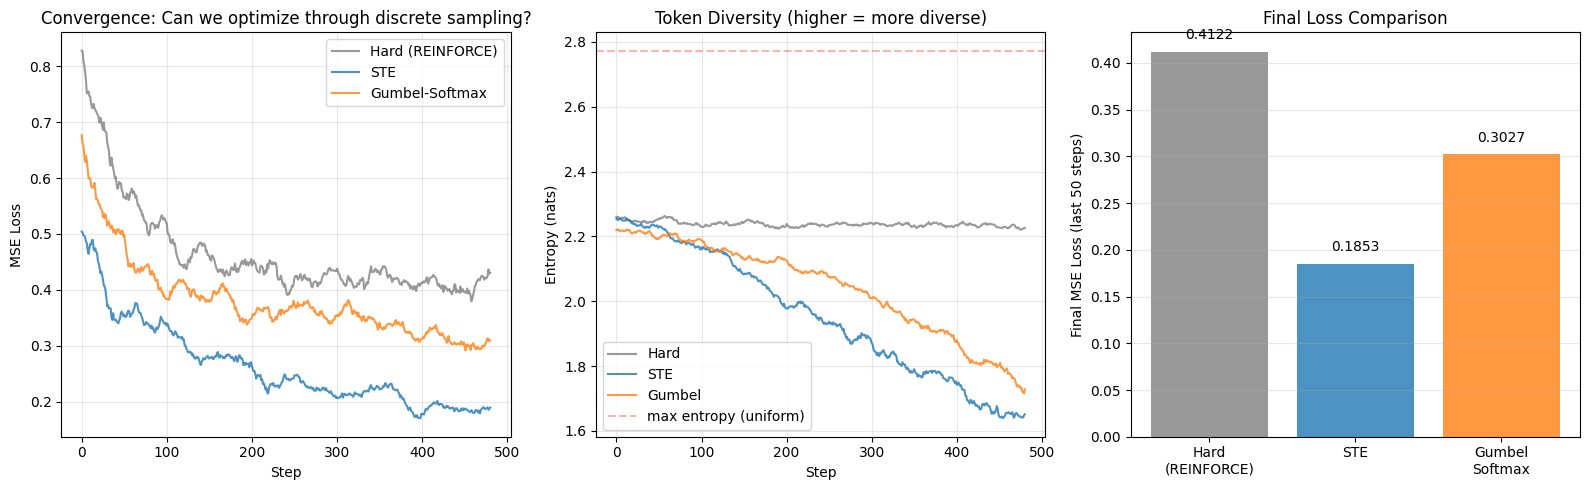

Saved to ./figure/diff_search_toy.png


In [39]:
# ============================================================
# Visualization: Loss convergence + Token diversity
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Loss curves ---
ax = axes[0]
window = 20
def smooth(x, w=window):
    return np.convolve(x, np.ones(w)/w, mode='valid')

ax.plot(smooth(losses_hard), label="Hard (REINFORCE)", alpha=0.8, color="gray")
ax.plot(smooth(losses_ste), label="STE", alpha=0.8, color="tab:blue")
ax.plot(smooth(losses_gumbel), label="Gumbel-Softmax", alpha=0.8, color="tab:orange")
ax.set_xlabel("Step"); ax.set_ylabel("MSE Loss")
ax.set_title("Convergence: Can we optimize through discrete sampling?")
ax.legend(); ax.grid(True, alpha=0.3)

# --- Token entropy (diversity) ---
ax = axes[1]
ax.plot(smooth(ent_hard), label="Hard", alpha=0.8, color="gray")
ax.plot(smooth(ent_ste), label="STE", alpha=0.8, color="tab:blue")
ax.plot(smooth(ent_gumbel), label="Gumbel", alpha=0.8, color="tab:orange")
ax.axhline(y=np.log(V_abs), color='r', linestyle='--', alpha=0.3, label=f'max entropy (uniform)')
ax.set_xlabel("Step"); ax.set_ylabel("Entropy (nats)")
ax.set_title("Token Diversity (higher = more diverse)")
ax.legend(); ax.grid(True, alpha=0.3)

# --- Final loss comparison ---
ax = axes[2]
final_n = 50
methods = ["Hard\n(REINFORCE)", "STE", "Gumbel\nSoftmax"]
final_losses = [np.mean(losses_hard[-final_n:]),
                np.mean(losses_ste[-final_n:]),
                np.mean(losses_gumbel[-final_n:])]
colors = ["gray", "tab:blue", "tab:orange"]
bars = ax.bar(methods, final_losses, color=colors, alpha=0.8)
ax.set_ylabel("Final MSE Loss (last 50 steps)")
ax.set_title("Final Loss Comparison")
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, final_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("./figure/diff_search_toy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ./figure/diff_search_toy.png")

## Part 3: STE Applied to Jacobi Recursion (Simulated)

Now simulate the actual SoRL pattern: multiple positions need abstract tokens, 
and the last iteration of Jacobi decoding is made differentiable via STE.

The model does K iterations of refinement. Iterations 1..K-1 are no-grad (normal Jacobi).
**Only the last iteration uses STE** — so the final abstraction choice carries gradients
back through the logits that produced it.

In [ ]:
# ============================================================
# Simulated Jacobi Recursion with STE on last iteration
# ============================================================
# This mimics the SoRL pattern:
#   - A sequence has N_abs abstract positions
#   - Each position gets refined over K iterations (Jacobi)
#   - Iterations 1..K-1: normal hard sampling (no grad)
#   - Iteration K: STE sampling (differentiable)
#   - Downstream: sequence embedding → loss

class JacobiAbstractSearch(nn.Module):
    """
    Simulated Jacobi recursion for abstract token search.
    
    Architecture:
      - context_encoder: encodes surrounding NL tokens → hidden state per abs position
      - abs_predictor: hidden → logits over abstract vocab (refined each iteration)
      - abs_embed: abstract token embeddings
      - downstream: uses full sequence (NL + abstract embeddings) to predict target
    """
    def __init__(self, n_positions, hidden_dim, abs_vocab_size, embed_dim):
        super().__init__()
        self.n_positions = n_positions
        self.abs_vocab_size = abs_vocab_size

        # Per-position context (simulates transformer hidden states at abs positions)
        self.context_encoder = nn.Linear(hidden_dim, hidden_dim)
        # Refiner: takes (context, current_abs_embed) → new logits
        self.refiner = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, abs_vocab_size),
        )
        self.abs_embed = nn.Embedding(abs_vocab_size, embed_dim)
        # Downstream: aggregate all position embeddings → scalar
        self.downstream = nn.Linear(n_positions * embed_dim, 1)

    def forward(self, contexts, n_iterations=3, temperature=1.0, method="ste"):
        """
        contexts: (B, n_positions, hidden_dim) — context at each abstract position
        Returns: prediction, final_indices, all_logits_history
        """
        B = contexts.shape[0]
        h = self.context_encoder(contexts)  # (B, N, H)

        # Initialize abstract tokens randomly
        current_idx = torch.randint(0, self.abs_vocab_size, (B, self.n_positions), device=contexts.device)
        logits_history = []

        for it in range(n_iterations):
            current_emb = self.abs_embed(current_idx)  # (B, N, E)
            cat = torch.cat([h, current_emb], dim=-1)  # (B, N, H+E)
            logits = self.refiner(cat)                   # (B, N, V_abs) -> this takes the role of a "predictor"
            logits_history.append(logits.detach())

            is_last = (it == n_iterations - 1)

            if is_last and method == "ste":
                # STE on last iteration — differentiable
                soft_probs = F.softmax(logits / max(temperature, 1e-5), dim=-1)  # (B, N, V)
                if temperature > 0:
                    hard_idx = torch.multinomial(
                        soft_probs.view(-1, self.abs_vocab_size), 1
                    ).view(B, self.n_positions)  # (B, N)
                else:
                    hard_idx = logits.argmax(dim=-1)
                
                one_hot = F.one_hot(hard_idx, self.abs_vocab_size).float()
                ste_probs = one_hot + soft_probs - soft_probs.detach()  # STE
                final_emb = torch.einsum('bnv,ve->bne', ste_probs, self.abs_embed.weight)
                current_idx = hard_idx

            elif is_last and method == "gumbel":
                soft = F.gumbel_softmax(logits, tau=max(temperature, 1e-5), hard=True, dim=-1)
                final_emb = torch.einsum('bnv,ve->bne', soft, self.abs_embed.weight)
                current_idx = soft.argmax(dim=-1)

            else:
                # Hard sampling (no grad) — all non-last iterations, or method=="hard"
                with torch.no_grad():
                    if temperature > 0:
                        probs = F.softmax(logits / temperature, dim=-1)
                        current_idx = torch.multinomial(
                            probs.view(-1, self.abs_vocab_size), 1
                        ).view(B, self.n_positions)
                    else:
                        current_idx = logits.argmax(dim=-1)
                if is_last:
                    final_emb = self.abs_embed(current_idx)  # no gradient to logits

        # Downstream prediction from final abstract embeddings
        flat_emb = final_emb.view(B, -1)  # (B, N*E)
        pred = self.downstream(flat_emb).squeeze(-1)  # (B,)

        return pred, current_idx, logits_history


N_POS = 4   # number of abstract positions
H = 32
V_abs = 16
E = 16

jacobi_model = JacobiAbstractSearch(N_POS, H, V_abs, E).to(device)
print(f"Jacobi model: {N_POS} positions, {V_abs} vocab, {3} iterations")
print(f"Only last iteration is differentiable (STE/Gumbel)")

Jacobi model: 4 positions, 16 vocab, 3 iterations
Only last iteration is differentiable (STE/Gumbel)


In [ ]:
# ============================================================
# Train Jacobi model with all 3 methods — compare convergence
# ============================================================

# Target: a fixed random projection from contexts → scalar
jacobi_target = nn.Linear(N_POS * H, 1, bias=False).to(device)
for p in jacobi_target.parameters():
    p.requires_grad = False


def train_jacobi(method, n_steps=800, lr=1e-3, temperature=0.5, n_iters=3):
    mdl = JacobiAbstractSearch(N_POS, H, V_abs, E).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=lr)
    losses = []
    token_counts = []  # track unique tokens chosen

    for step in range(n_steps):
        contexts = torch.randn(B, N_POS, H, device=device)
        target = jacobi_target(contexts.view(B, -1)).squeeze(-1)

        pred, idx, _ = mdl(contexts, n_iterations=n_iters,
                           temperature=temperature, method=method)
        loss = F.mse_loss(pred, target.detach())

        opt.zero_grad()
        if method == "hard":
            # REINFORCE for predictor gradients
            with torch.no_grad():
                reward = -loss.item()
            # Re-forward to get logits with grad for REINFORCE
            h = mdl.context_encoder(contexts)
            current_emb = mdl.abs_embed(idx)
            cat = torch.cat([h, current_emb], dim=-1) # ensembled rep from NL context and abstract idx
            logits = mdl.refiner(cat) # 
            log_probs = F.log_softmax(logits / temperature, dim=-1)
            selected_lp = log_probs.gather(2, idx.unsqueeze(-1)).squeeze(-1)
            reinforce_loss = -(reward * selected_lp).mean()
            
            # Combine: reinforce for predictor (logits), normal loss for downstream/embed
            total_loss = reinforce_loss + loss
            total_loss.backward()
        else:
            loss.backward()

        opt.step()
        losses.append(loss.item())

        # Token diversity
        unique = len(idx.unique())
        token_counts.append(unique)

    return losses, token_counts


print("Training Jacobi model (3 iterations, STE on last)...")
print("  Method: hard (REINFORCE)...")
j_losses_hard, j_tc_hard = train_jacobi("hard", n_steps=800, temperature=0.5)
print("  Method: STE...")
j_losses_ste, j_tc_ste = train_jacobi("ste", n_steps=800, temperature=0.5)
print("  Method: Gumbel-Softmax...")
j_losses_gumbel, j_tc_gumbel = train_jacobi("gumbel", n_steps=800, temperature=0.5)
print("Done.")

Training Jacobi model (3 iterations, STE on last)...
  Method: hard (REINFORCE)...
  Method: STE...
  Method: Gumbel-Softmax...
Done.


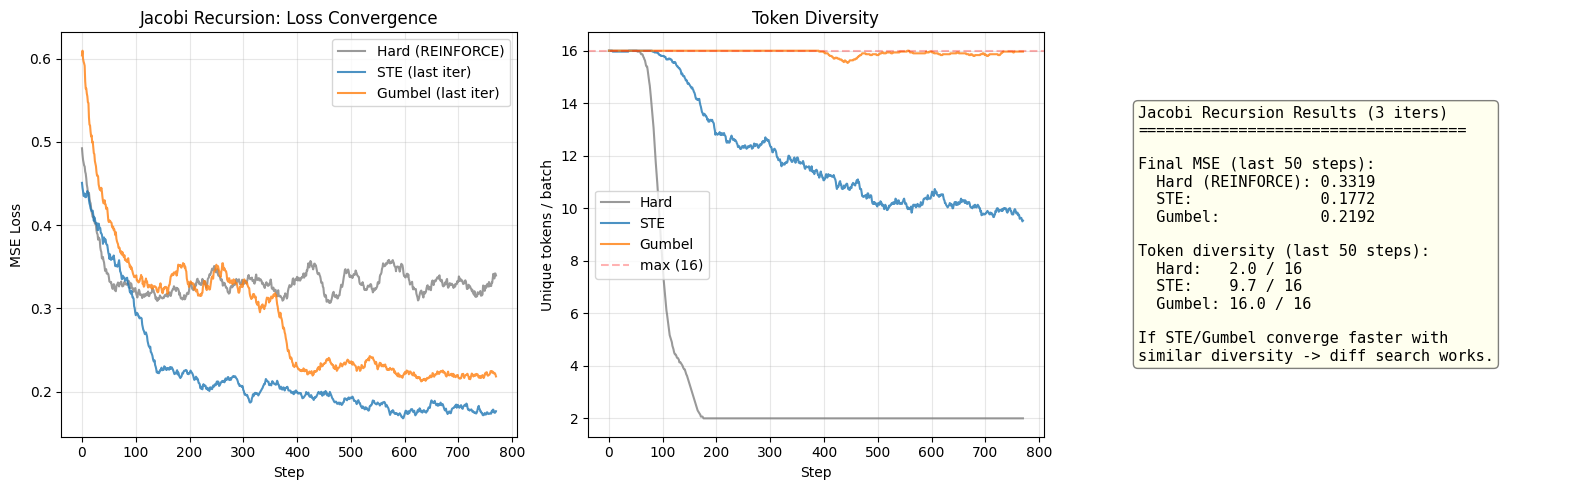

Saved to ./figure/diff_search_jacobi.png


In [46]:
# ============================================================
# Visualization: Jacobi recursion comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
window = 30

ax = axes[0]
ax.plot(smooth(j_losses_hard, window), label="Hard (REINFORCE)", alpha=0.8, color="gray")
ax.plot(smooth(j_losses_ste, window), label="STE (last iter)", alpha=0.8, color="tab:blue")
ax.plot(smooth(j_losses_gumbel, window), label="Gumbel (last iter)", alpha=0.8, color="tab:orange")
ax.set_xlabel("Step"); ax.set_ylabel("MSE Loss")
ax.set_title("Jacobi Recursion: Loss Convergence")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(smooth(j_tc_hard, window), label="Hard", alpha=0.8, color="gray")
ax.plot(smooth(j_tc_ste, window), label="STE", alpha=0.8, color="tab:blue")
ax.plot(smooth(j_tc_gumbel, window), label="Gumbel", alpha=0.8, color="tab:orange")
ax.axhline(y=V_abs, color='r', linestyle='--', alpha=0.3, label=f'max ({V_abs})')
ax.set_xlabel("Step"); ax.set_ylabel("Unique tokens / batch")
ax.set_title("Token Diversity")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.axis('off')
final_n = 50
summary = (
    f"Jacobi Recursion Results (3 iters)\n"
    f"{'='*36}\n\n"
    f"Final MSE (last {final_n} steps):\n"
    f"  Hard (REINFORCE): {np.mean(j_losses_hard[-final_n:]):.4f}\n"
    f"  STE:              {np.mean(j_losses_ste[-final_n:]):.4f}\n"
    f"  Gumbel:           {np.mean(j_losses_gumbel[-final_n:]):.4f}\n\n"
    f"Token diversity (last {final_n} steps):\n"
    f"  Hard:   {np.mean(j_tc_hard[-final_n:]):.1f} / {V_abs}\n"
    f"  STE:    {np.mean(j_tc_ste[-final_n:]):.1f} / {V_abs}\n"
    f"  Gumbel: {np.mean(j_tc_gumbel[-final_n:]):.1f} / {V_abs}\n\n"
    f"If STE/Gumbel converge faster with\n"
    f"similar diversity -> diff search works."
)
ax.text(0.05, 0.5, summary, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig("./figure/diff_search_jacobi.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ./figure/diff_search_jacobi.png")

In [47]:
# Observation: 
# - "REINFORECE" loss, despite trains on predictor (refines abstract idx) and embedding moddule, suffers from
#   vocabulary collapse (predictor collapse into predicting repeatitive tokens) and focus on updating the embedding
#   model only, this is suspiciously similar to the behavior of SoRL, when it collapse its vocabulary
# - STE estimator, applied to the last iteration in the "recursion" (refines abstract idx via Jacobi decoding method)
#   avoids such issue, enables predictor to spot diverse abstraction whilst achieving the best loss overall

    

## Part 4: SoRL Integration Sketch

How this would plug into the real `SoRLTrainerv3._training_step()`:

```python
# In sorl_wrapper.py — recursion() modified:
def recursion_diff(self, idx, attention_mask, max_iterations=5, temperature=1.0, ...):
    """Jacobi recursion with STE on the last iteration."""
    for it in range(max_iterations):
        outputs = self.model.forward(input_ids=idx, attention_mask=attention_mask, ...)
        logits = outputs.logits
        
        if it < max_iterations - 1:
            # Normal hard sampling (no grad)
            idx = self.extract_and_sample(logits, idx, recursion_mask, temperature)
        else:
            # Last iteration: STE
            # For each abstract position, replace hard index with STE embedding
            abs_logits = logits[:, abs_positions, vocab_size_0:]  # (B, N_abs, V_abs)
            soft_probs = F.softmax(abs_logits / temperature, dim=-1)
            hard_idx = torch.multinomial(soft_probs.view(-1, V_abs), 1).view(B, N_abs)
            one_hot = F.one_hot(hard_idx, V_abs).float()
            ste_probs = one_hot + soft_probs - soft_probs.detach()
            # This ste_probs can be used in the loss computation
            # instead of looking up embeddings by index
    
    return idx, per_token_loss, ste_probs  # ste_probs carries gradient
```

Key insight: only the **last iteration** needs STE. Earlier iterations are exploratory
and can use standard hard sampling. This keeps the cost identical to current Jacobi.

## Part 7: STE-SoRL Integration — Real Training Pipeline

Integrate STE into the actual SoRL training pipeline. Key insight from the toy experiments:
**STE provides dense gradients, so multiple rollouts are unnecessary** (cf. HRM — recursion replaces search).

**Architecture (single-rollout, end-to-end differentiable):**
1. Insert abstract tokens into input sequence
2. `recursion(differentiable=True)` — N-1 hard Jacobi iterations + 1 STE iteration + final STE-embed forward
3. Decompose returned logits into `traj_loss` (base vocab) and `abs_loss` (abstract vocab)
4. Optional: corrupted hinge loss for contrastive signal

**Gradient path:** `loss → final forward (inputs_embeds) → STE probs → last-iter logits → model params`

This is the correct gradient path: the STE logits come from the actual last recursion iteration
(which conditions on the previous iteration's abstract tokens), not a synthetic re-forward.

In [61]:
# ============================================================
# SoRL + STE: Setup
# ============================================================
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time, json

if hasattr(torch.backends, 'mps'):
    torch.backends.mps.is_available = lambda: False

from transformers import AutoTokenizer
from sorl.sorl_wrapper import SorlModelWrapper
from sorl.sorl_trainer import (
    sorl_search, corrupt_abstract_tokens,
    infer_insert_mask, expand_prompt_len, insert_tokens_with_padding,
)
from data.pt_dataset import get_dataset, evaluate_accuracy, collate_fn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Config ----
cfg = dict(
    model_name    = "Qwen/Qwen3-0.6B",
    abs_vocab     = 128,
    dataset       = "gsm8k",
    max_length    = 256,
    batch_size    = 2,

    # Recursion
    K             = 4,
    max_iters     = 2,
    temperature   = 1.0,
    mem_span_abs  = 1792,
    mem_span_traj = 1792,

    # Corruption
    corrupt_method = "shuffle",
    corrupt_ratio  = 0.3,

    # Loss weights
    alpha_traj        = 1.0,
    alpha_contrastive = 1.0,
    alpha_abs         = 0.5,
    gamma             = 0.5,

    # Optimizer
    lr            = 1e-5,
    emb_lr_mult   = 1.0,
    weight_decay  = 0.01,
    max_grad_norm = 1.0,
    warmup_steps  = 50,
    cooldown_frac = 0.4,

    # Training
    num_epochs    = 3,
    grad_accum    = 4,
    log_every     = 10,
)

# ---- Model + Data ----
model = SorlModelWrapper.from_pretrained(cfg["model_name"], abstract_vocab_size_list=[cfg["abs_vocab"]])
model = model.to(device).train()
tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
pad_token_id = tokenizer.pad_token_id
base_vocab = int(model.vocab_sizes[0].item())
total_vocab = int(model.vocab_sizes.sum().item())

train_ds = get_dataset(cfg["dataset"], split="train", tokenizer=tokenizer, max_length=cfg["max_length"])
dl = torch.utils.data.DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True, collate_fn=collate_fn, num_workers=0)

# ---- Optimizer (separate LR for embeddings) ----
emb_params, other_params = [], []
for name, p in model.named_parameters():
    if "embed_tokens" in name or "lm_head" in name:
        emb_params.append(p)
    else:
        other_params.append(p)
optimizer = torch.optim.AdamW([
    {"params": other_params, "lr": cfg["lr"]},
    {"params": emb_params,   "lr": cfg["lr"] * cfg["emb_lr_mult"]},
], weight_decay=cfg["weight_decay"])

total_steps = len(dl) * cfg["num_epochs"] // cfg["grad_accum"]
print(f"Device: {device} | Train: {len(train_ds)} | Steps: {total_steps}")
print(f"Effective batch: {cfg['batch_size'] * cfg['grad_accum']}")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Device: cpu | Train: 7473 | Steps: 2802
Effective batch: 8


In [58]:
# Note are what's left for Human in the age of Agentic AI I suppose

# Q1. If we are using the "ste_probs" to conduct differentiable readout, then is "idx" still relevant? 
# read out from embedding is using entirely "ste_probs" right? So why do we need multiple rollouts, 
# instead of just one rollout with gradient?

# Q2. Why do we need "2 passes" to compute gradient, given the "best data" -- is this the optimal way 
#     of computing gradient? The natural way, should be to recurse 2 times, the 2nd time we track gradient
#     on the choice of abstract tokens (abstract_idx is replaced with ste_abstract_logit), then the 3rd
#     time becomes a gradient enabled forward pass that fianlly computes the perplexity on traj / abs tokens

# Q3. How to make sense of the "2 pass" logic? It forces gradient when we chose the abstraction token

# Issue #1. Pass 1 wrongly assumes the model need to "predict a given a", where a is the 
#           actually recursed from [abs_mask], the legitimate way to do it, is if we "record"
#           the input sequence [t t t a t t t a] before the last recursion (for the best rollout)
#           if we don't have that, there is no way to simulate the correct gradient path

# Idea #1. A hacky thing to do (if we find multiple rollouts to be necessary, which is unlikely if 
# we consider works like HRM -- they usually use multiple recursion to replace "searches" -- rightly
# so ebcause recursion is differentiable, and easier to optimize, given the above experiment result, I
# would think we probably don't need multiple rollouts anyway) 
# But the hack is to take [mask_abstraction] as input, and treat [select_abstract] as the target
# -- this is not end-to-end optimization, but a process supervision, quite ugly to be honest

# Therefore it's better to just take one rollout, with gradient enabled (for the final recursion 
# step, as well as the loss propagation after the recursion)

In [62]:
# ============================================================
# Loss Decomposition + Helpers
# ============================================================
# With recursion(differentiable=True), we get (idx, per_token_loss, logits) where
# logits carry STE gradients. We decompose into traj_loss and abs_loss here.

def decompose_losses(idx, logits, attention_mask, prompt_len, bv):
    """
    Decompose full-vocab logits into separated traj_loss and abs_loss.
    
    Args:
        idx: (B, L) — final token sequence (with abstract tokens)
        logits: (B, L, V) — logits from recursion's final forward pass (STE-enabled)
        attention_mask: (B, L)
        prompt_len: (B,) — number of prompt tokens per sample  
        bv: int — base vocab size (tokens < bv are NL, >= bv are abstract)
    
    Returns: traj_loss, abs_loss (both with STE gradients)
    """
    B, L = idx.shape
    
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = idx[..., 1:].contiguous()
    shift_attn = attention_mask[..., 1:].contiguous().clone()
    
    # Mask out prompt tokens from loss
    if prompt_len is not None:
        seq_idx = torch.arange(shift_attn.size(1), device=idx.device).unsqueeze(0)
        shift_attn[seq_idx < (prompt_len.unsqueeze(1) - 1)] = 0
    
    # Level masks: traj = NL tokens, abs = abstract tokens
    levels = (idx >= bv).long()[:, 1:]
    traj_mask = (levels == 0).float() * shift_attn.float()
    abs_mask  = (1 - traj_mask) * shift_attn.float()
    
    loss_fct = nn.CrossEntropyLoss(reduction='none')
    
    # traj_loss: CE over base vocab only (mask abstract logits)
    traj_logits = shift_logits.clone()
    traj_logits[..., bv:] = -float("inf")
    safe_traj = shift_labels.clone()
    safe_traj[~traj_mask.bool()] = 0
    traj_ce = loss_fct(traj_logits.view(-1, traj_logits.size(-1)), safe_traj.view(-1))
    traj_loss = (traj_ce.view(B, -1) * traj_mask).sum() / traj_mask.sum().clamp(min=1)
    
    # abs_loss: CE over abstract vocab only (mask base logits)
    abs_logits = shift_logits.clone()
    abs_logits[..., :(bv + 1)] = -float("inf")
    safe_abs = shift_labels.clone()
    safe_abs[~abs_mask.bool()] = bv + 1
    abs_ce = loss_fct(abs_logits.view(-1, abs_logits.size(-1)), safe_abs.view(-1))
    abs_loss = (abs_ce.view(B, -1) * abs_mask).sum() / abs_mask.sum().clamp(min=1)
    
    return traj_loss, abs_loss


def compute_corrupted_traj_loss(model, corrupted_data, attention_mask, mem_abs, mem_traj, prompt_len):
    """Corrupted trajectory loss (no grad) for hinge contrastive."""
    bv = int(model.vocab_sizes[0].item())
    with torch.no_grad():
        outputs = model(
            input_ids=corrupted_data, attention_mask=attention_mask,
            memory_span_abs=mem_abs, memory_span_traj=mem_traj,
        )
        shift_logits = outputs.logits[..., :-1, :].contiguous()
        shift_labels = corrupted_data[..., 1:].contiguous()
        shift_attn = attention_mask[..., 1:].contiguous().clone()
        if prompt_len is not None:
            seq_idx = torch.arange(shift_attn.size(1), device=corrupted_data.device).unsqueeze(0)
            shift_attn[seq_idx < (prompt_len.unsqueeze(1) - 1)] = 0
        
        levels = (corrupted_data >= bv).long()[:, 1:]
        traj_mask = (levels == 0).float() * shift_attn.float()
        
        traj_logits = shift_logits.clone()
        traj_logits[..., bv:] = -float("inf")
        safe_labels = shift_labels.clone()
        safe_labels[~traj_mask.bool()] = 0
        
        loss_fct = nn.CrossEntropyLoss(reduction='none')
        c_losses = loss_fct(traj_logits.view(-1, traj_logits.size(-1)), safe_labels.view(-1))
        c_traj_loss = (c_losses.view(corrupted_data.shape[0], -1) * traj_mask).sum() / traj_mask.sum().clamp(min=1)
    return c_traj_loss


def get_lr(step, total_steps, warmup_steps, cooldown_frac, base_lr):
    """Linear warmup → constant → cosine cooldown."""
    cooldown_start = int(total_steps * (1 - cooldown_frac))
    if step < warmup_steps:
        return base_lr * step / max(warmup_steps, 1)
    elif step < cooldown_start:
        return base_lr
    else:
        progress = (step - cooldown_start) / max(total_steps - cooldown_start, 1)
        return base_lr * 0.5 * (1 + np.cos(np.pi * progress))


print("Loss decomposition + helper functions defined.")

Loss decomposition + helper functions defined.


In [63]:
# ============================================================
# SoRL + STE Training Loop (Single Rollout, End-to-End)
# ============================================================
# 1. Insert abstract tokens
# 2. recursion(differentiable=True) — N-1 hard iters + 1 STE iter + STE-embed forward
# 3. decompose_losses from returned logits → traj_loss, abs_loss
# 4. Corrupted hinge contrastive
# 5. total_loss → backward

model.train()
optimizer.zero_grad()

log = {"step": [], "traj_loss": [], "abs_loss": [], "hinge_loss": [], "total_loss": [], "lr": []}
global_step = 0
micro_step = 0

for epoch in range(cfg["num_epochs"]):
    for batch_idx, batch in enumerate(dl):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        prompt_len = batch["prompt_len"].to(device)

        # ---- Step 1: Insert abstract tokens ----
        insert_mask = infer_insert_mask(input_ids, cfg["K"], attention_mask)
        exp_pl = expand_prompt_len(prompt_len, insert_mask)
        exp_data, exp_mask = insert_tokens_with_padding(
            input_ids, attention_mask, insert_mask,
            model.vocab_sizes[0], pad_token_id,
        )

        # ---- Step 2: Single differentiable recursion ----
        idx, per_token_loss, logits = model.recursion(
            exp_data, exp_mask,
            max_iterations=cfg["max_iters"],
            memory_span_abs=cfg["mem_span_abs"],
            memory_span_traj=cfg["mem_span_traj"],
            temperature=cfg["temperature"],
            prompt_len=exp_pl,
            differentiable=True,
        )

        # ---- Step 3: Decompose into traj/abs losses ----
        traj_loss, abs_loss = decompose_losses(idx, logits, exp_mask, exp_pl, base_vocab)

        # ---- Step 4: Corrupted traj loss for hinge ----
        corrupted_data = corrupt_abstract_tokens(
            idx.detach(), base_vocab, total_vocab,
            method=cfg["corrupt_method"], corrupt_ratio=cfg["corrupt_ratio"],
        )
        c_traj_loss = compute_corrupted_traj_loss(
            model, corrupted_data, exp_mask,
            cfg["mem_span_abs"], cfg["mem_span_traj"], exp_pl,
        )

        # ---- Step 5: Combine losses ----
        hinge_loss = (cfg["gamma"] + traj_loss - c_traj_loss).clamp(min=0)
        
        total_loss = (
            cfg["alpha_traj"] * traj_loss
            + cfg["alpha_abs"] * abs_loss
            + cfg["alpha_contrastive"] * hinge_loss
        ) / cfg["grad_accum"]

        total_loss.backward()
        micro_step += 1

        if micro_step % cfg["grad_accum"] == 0:
            # LR schedule
            lr = get_lr(global_step, total_steps, cfg["warmup_steps"],
                        cfg["cooldown_frac"], cfg["lr"])
            for pg in optimizer.param_groups:
                pg["lr"] = lr * (cfg["emb_lr_mult"] if pg is optimizer.param_groups[1] else 1.0)

            nn.utils.clip_grad_norm_(model.parameters(), cfg["max_grad_norm"])
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1

            # Logging
            if global_step % cfg["log_every"] == 0:
                log["step"].append(global_step)
                log["traj_loss"].append(traj_loss.item())
                log["abs_loss"].append(abs_loss.item())
                log["hinge_loss"].append(hinge_loss.item())
                log["total_loss"].append(total_loss.item() * cfg["grad_accum"])
                log["lr"].append(lr)
                print(f"[E{epoch+1} S{global_step:4d}] "
                      f"traj={traj_loss.item():.3f} abs={abs_loss.item():.3f} "
                      f"hinge={hinge_loss.item():.3f} total={log['total_loss'][-1]:.3f} "
                      f"lr={lr:.2e}")

print(f"\nTraining complete. {global_step} optimizer steps.")

RuntimeError: expected m1 and m2 to have the same dtype, but got: float != c10::BFloat16

In [ ]:
# ============================================================
# Visualization: SoRL + STE Training Curves
# ============================================================

if len(log["step"]) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ax = axes[0]
    ax.plot(log["step"], log["traj_loss"], label="traj_loss", color="tab:blue")
    ax.plot(log["step"], log["abs_loss"], label="abs_loss", color="tab:orange")
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.set_title("SoRL+STE: Trajectory & Abstraction Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(log["step"], log["hinge_loss"], label="hinge_loss", color="tab:red")
    ax.plot(log["step"], log["total_loss"], label="total_loss", color="tab:purple")
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.set_title("SoRL+STE: Hinge & Total Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.plot(log["step"], log["lr"], color="tab:green")
    ax.set_xlabel("Step"); ax.set_ylabel("Learning Rate")
    ax.set_title("LR Schedule")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("./figure/diff_search_sorl_ste.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to ./figure/diff_search_sorl_ste.png")
else:
    print("No training logs to plot.")